# Sales Data Analysis #

## 1️. Import Libraries ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2️. Load the Dataset ##

In [3]:
df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


 ## 3. Check Dataset Shape ##

In [5]:
df.shape

(2823, 25)

## 4.Sales by Product Line ##

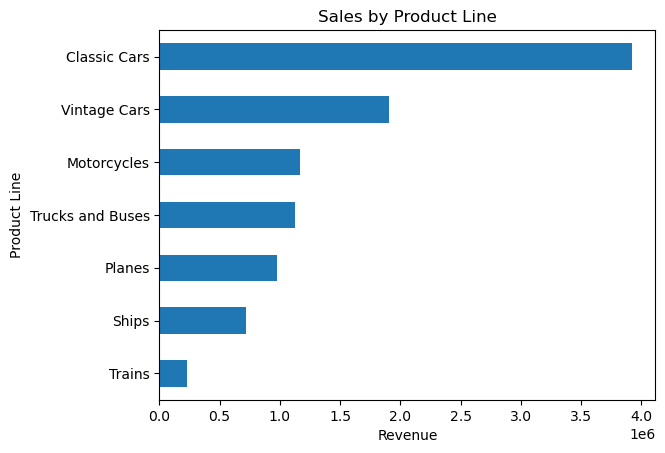

In [7]:
product_sales = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values()

plt.figure()

product_sales.plot(kind="barh")

plt.title("Sales by Product Line")
plt.xlabel("Revenue")
plt.ylabel("Product Line")

plt.show()

## 5️. Monthly Sales Trend ##

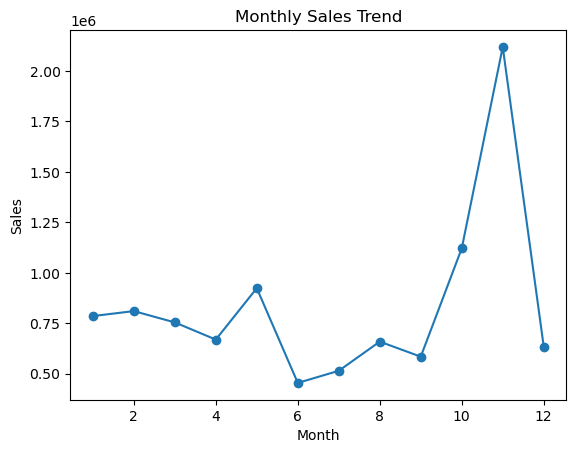

In [9]:
monthly_sales = df.groupby("MONTH_ID")["SALES"].sum()

plt.figure()

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

## 6️. Top 10 Customers ##

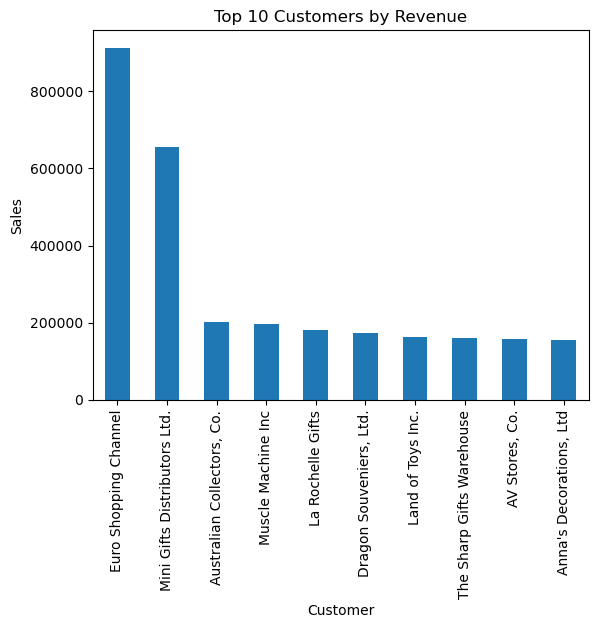

In [11]:
top_customers = df.groupby("CUSTOMERNAME")["SALES"].sum().sort_values(ascending=False).head(10)

plt.figure()

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

## 7️. Sales by Country ##

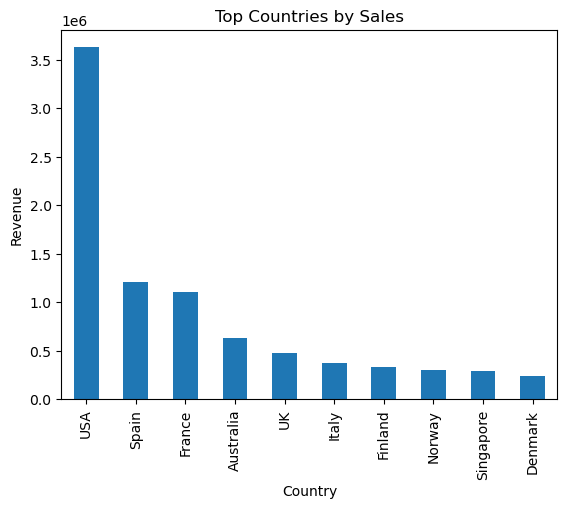

In [13]:
country_sales = df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False)

plt.figure()

country_sales.head(10).plot(kind="bar")

plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

## 8️. Deal Size Distribution

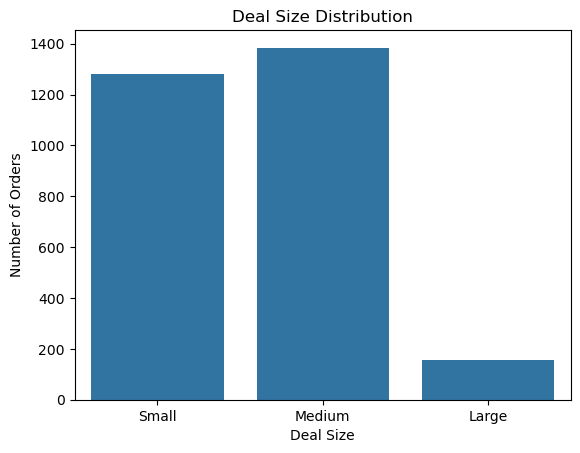

In [15]:
plt.figure()

sns.countplot(data=df, x="DEALSIZE")

plt.title("Deal Size Distribution")
plt.xlabel("Deal Size")
plt.ylabel("Number of Orders")

plt.show()

## 9.Correlation Heatmap

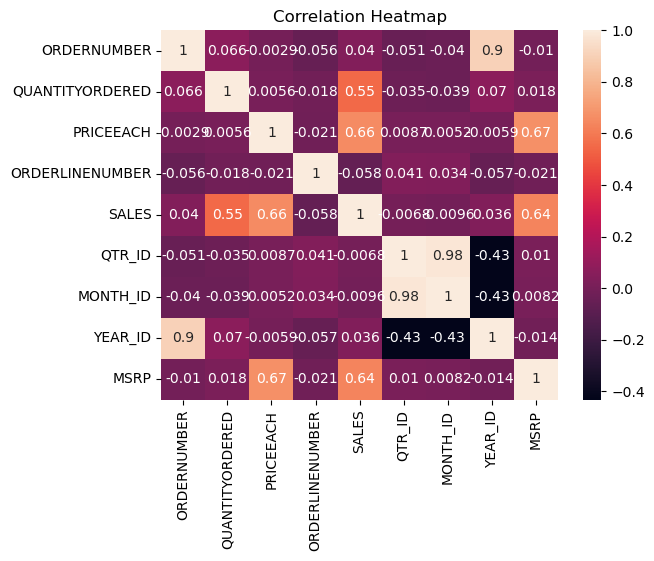

In [17]:
plt.figure()

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

## 10.Yearly Sales Performance

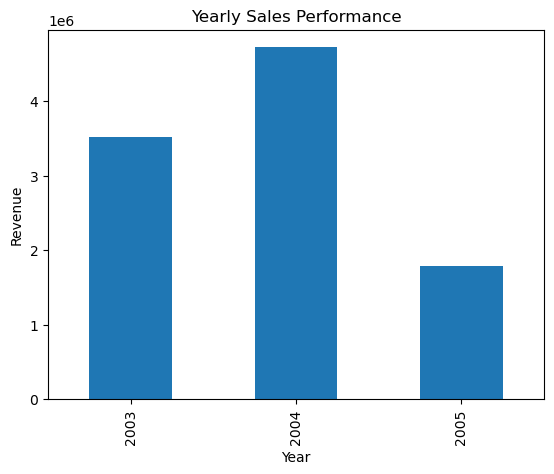

In [19]:
year_sales = df.groupby("YEAR_ID")["SALES"].sum()

plt.figure()

year_sales.plot(kind="bar")

plt.title("Yearly Sales Performance")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

## 11.Sales Distribution (Histogram)

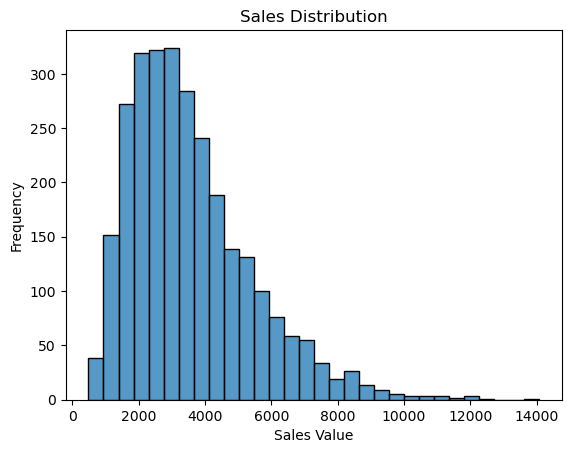

In [21]:
plt.figure()

sns.histplot(df["SALES"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales Value")
plt.ylabel("Frequency")

plt.show()

## 12.Product Line vs Sales (Box Plot)

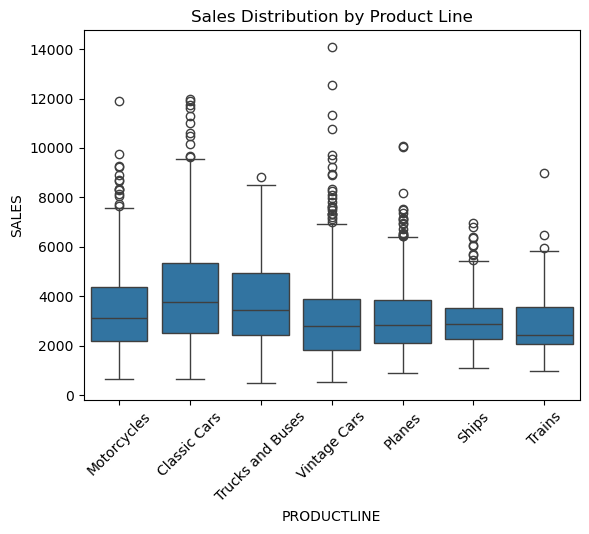

In [23]:
plt.figure()

sns.boxplot(data=df, x="PRODUCTLINE", y="SALES")

plt.xticks(rotation=45)

plt.title("Sales Distribution by Product Line")

plt.show()

## 13.Monthly Sales Heatmap

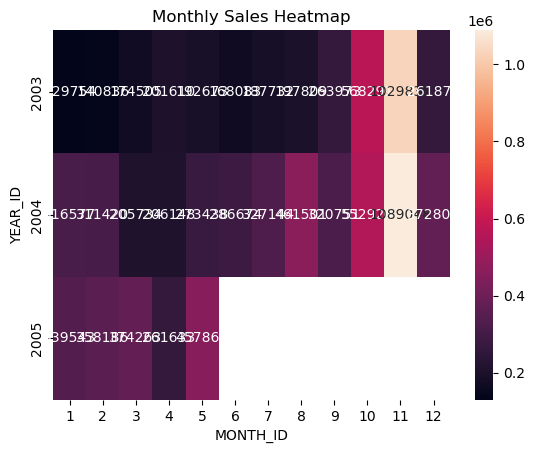

In [25]:
sales_heatmap = df.pivot_table(
    values="SALES",
    index="YEAR_ID",
    columns="MONTH_ID",
    aggfunc="sum"
)

plt.figure()

sns.heatmap(sales_heatmap, annot=True, fmt=".0f")

plt.title("Monthly Sales Heatmap")

plt.show()

## 14.Top 10 Products

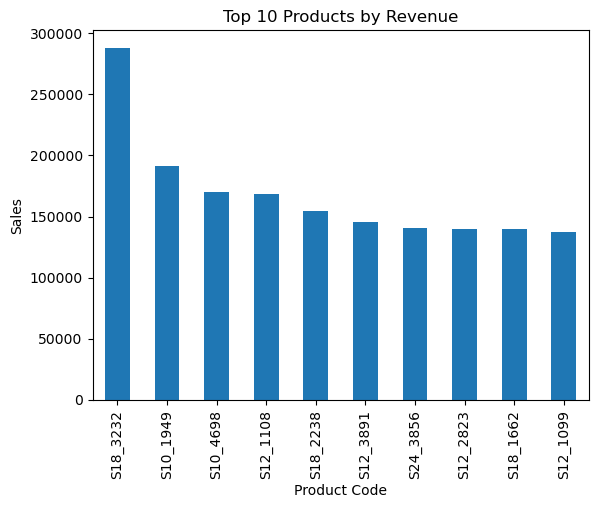

In [27]:
top_products = df.groupby("PRODUCTCODE")["SALES"].sum().sort_values(ascending=False).head(10)

plt.figure()

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Code")
plt.ylabel("Sales")

plt.show()

# Key Insights
### 1.Classic Cars generated the highest sales among all product lines.

### 2.The USA contributed the largest share of revenue, followed by other major markets.

### 3.A small number of top customers account for a significant portion of total sales.

### 4.Sales show seasonal trends, with certain months performing better than others.

### 5.Large deal sizes contribute the most revenue, indicating the importance of high-value transactions.